In [1]:
import numpy as np
import os
import sklearn.preprocessing
from umap import umap_ as umap
import wavemap_paper
%matplotlib widget
import matplotlib.pyplot as plt 
from matplotlib import cm
from matplotlib import pyplot as plt
import random
from wavemap_paper.helper_functions import RAND_STATE, set_rand_state, plot_inverse_mapping
import networkx as nx
import cylouvain
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import mplcursors

from cluster import *


# get working directory
os.chdir("d:\\MasterThesis")
os.getcwd()

'd:\\MasterThesis'

In [2]:
# Preprocess
from preprocess_bxr import *

fileDirectory_dissorg = "data\\test_data\\"
fileName_dissorg = 'testdata_results.bxr' # name of BXR file 

fileDirectory_excit = "data\\excit_data\\"
fileName_excit = '20240627-iPCS-1806-div35-iNeurons_00.bxr' # name of BXR file 

wf_dissorg = extract_waveforms_from_bxr(fileDirectory_dissorg, fileName_dissorg)
wf_excit = extract_waveforms_from_bxr(fileDirectory_excit, fileName_excit)

wf_dissorg_preprocessed = preprocess_waveforms(
    wf_dissorg,
    smoothing_method = 'gf',
    smoothing_kwargs={'sigma': 1},
    norm=True,
    export_csv=True,
    export_filename="mean_waveforms_preprocessed_dissorg_SMOOTH.csv")

wf_excit_preprocessed = preprocess_waveforms(
    wf_excit,
    smoothing_method = 'gf',
    smoothing_kwargs={'sigma': 1},
    norm=True,
    export_csv=True,
    export_filename="mean_waveforms_preprocessed_excit_SMOOTH.csv")

Saved 87 mean waveforms to: mean_waveforms_preprocessed_dissorg_SMOOTH.csv
Saved 807 mean waveforms to: mean_waveforms_preprocessed_excit_SMOOTH.csv


### Unsmoothed, unnormalised

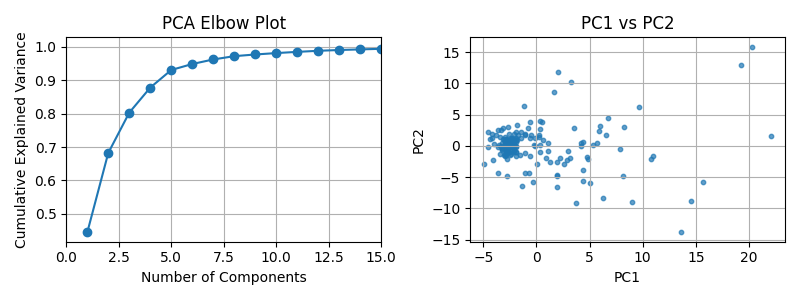

Components that explain 90% of variance: 5


In [3]:
data_path_excit = "d:\\MasterThesis\\mean_waveforms_preprocessed_excit_Test.csv"
data_path_dissorg = "d:\\MasterThesis\\mean_waveforms_preprocessed_dissorg_Test.csv"

data_list = [data_path_excit, data_path_dissorg]
data_labels = ['excitatory', 'dissorg']

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels)

# Run PCA
X_pca, pca, nc = run_pca(all_wf, n_exp_var = 0.9,plot = True)
print("Components that explain 90% of variance:", nc)

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


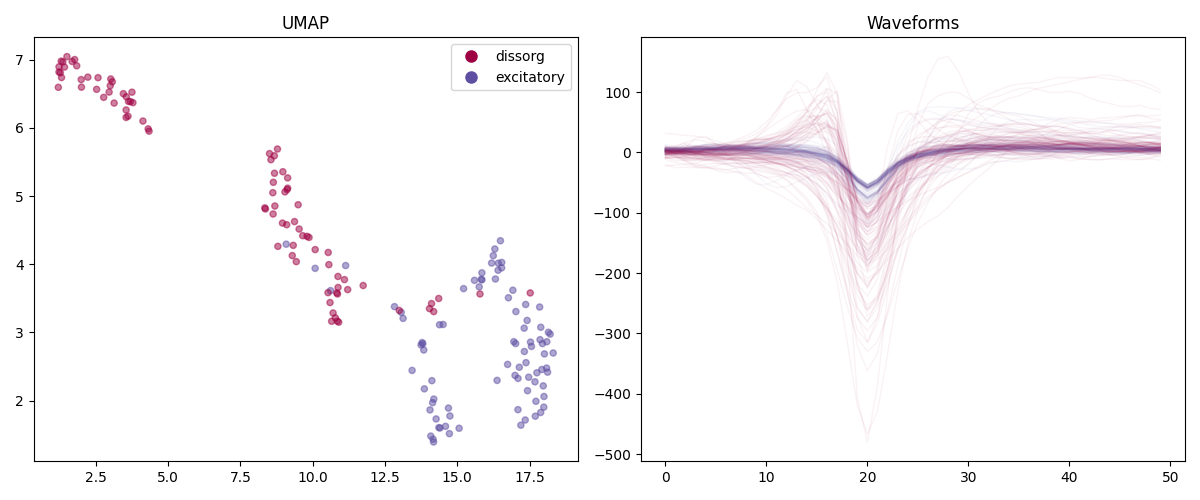

In [4]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# Run UMAP
umap_df, clustering_solution = run_umap(all_wf, all_labels, n_nb=15, min_d=0.1, n_comps=2, metric='euclidean', random_state=RAND_STATE)

# Plot UMAP
interactive_umap_plot(umap_df, cmap_name="Spectral")

### Smoothed and Normalised

gf, sigma = 2

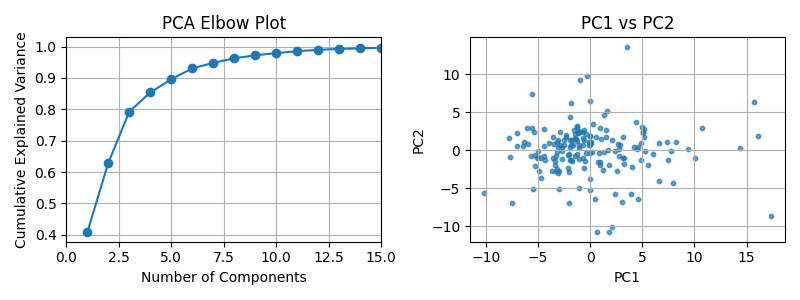

Components that explain 90% of variance: 6


In [5]:
data_path_excit = "d:\\MasterThesis\\mean_waveforms_preprocessed_excit_SMOOTH.csv"
data_path_dissorg = "d:\\MasterThesis\\mean_waveforms_preprocessed_dissorg_SMOOTH.csv"

data_list = [data_path_excit, data_path_dissorg]
data_labels = ['excitatory', 'dissorg']

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels)

# Run PCA
X_pca, pca, nc = run_pca(all_wf, n_exp_var = 0.9,plot = True)
print("Components that explain 90% of variance:", nc)

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


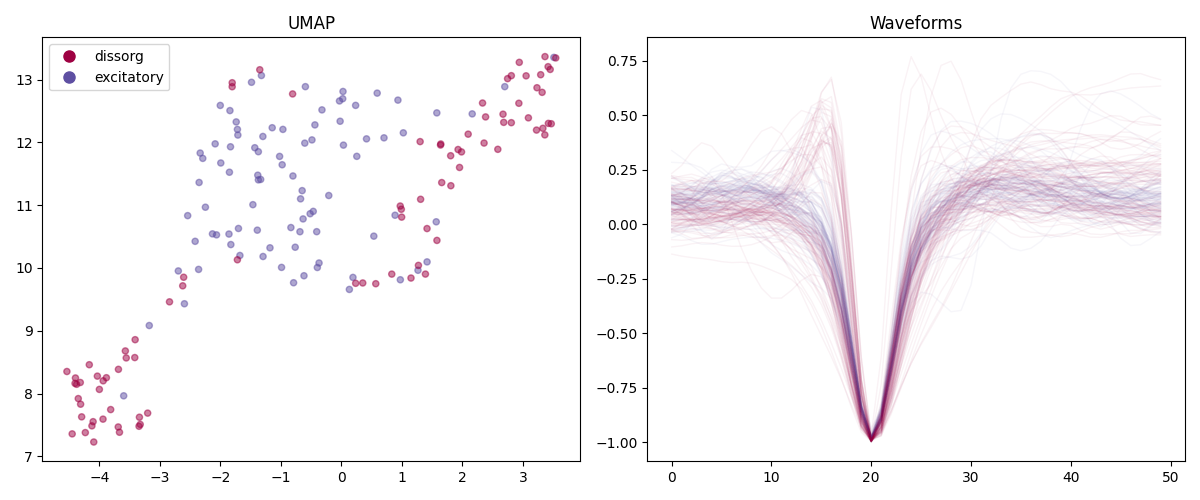

In [6]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# Run UMAP
umap_df, clustering_solution = run_umap(all_wf, all_labels, n_nb=15, min_d=0.1, n_comps=2, metric='euclidean', random_state=RAND_STATE)

# Plot UMAP
interactive_umap_plot(umap_df, cmap_name="Spectral")

Okay, so, it seems like I'm preprocessing all the single waves, and only at the end am I taking the mean. Maybe it's worth trying to take the mean after the filtering has happened. Will that make a difference?

Okay let's test this, functions have been updated

In [7]:
# New preprocessing, taking the mean first

from preprocess_bxr import *

fileDirectory_dissorg = "data\\test_data\\"
fileName_dissorg = 'testdata_results.bxr' # name of BXR file 

fileDirectory_excit = "data\\excit_data\\"
fileName_excit = '20240627-iPCS-1806-div35-iNeurons_00.bxr' # name of BXR file 

wf_dissorg = extract_waveforms_from_bxr(fileDirectory_dissorg, fileName_dissorg)
wf_excit = extract_waveforms_from_bxr(fileDirectory_excit, fileName_excit)

wf_dissorg_preprocessed = preprocess_waveforms_meanfirst(
    wf_dissorg,
    smoothing_method = 'gf',
    smoothing_kwargs={'sigma': 1.5},
    norm=True,
    export_csv=True,
    export_filename="mean_waveforms_preprocessed_dissorg_NEWPREP2.csv")

wf_excit_preprocessed = preprocess_waveforms_meanfirst(
    wf_excit,
    smoothing_method = 'gf',
    smoothing_kwargs={'sigma': 1.5},
    min_waveforms=100,  
    norm=True,
    export_csv=True,
    export_filename="mean_waveforms_preprocessed_excit_NEWPREP2.csv")

Saved 87 rows to: mean_waveforms_preprocessed_dissorg_NEWPREP2.csv
Saved 193 rows to: mean_waveforms_preprocessed_excit_NEWPREP2.csv


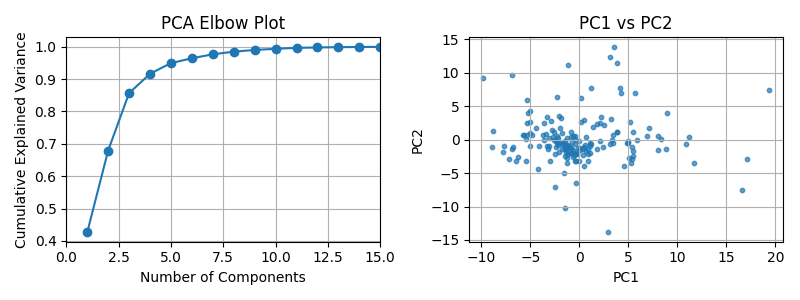

Components that explain 90% of variance: 4


In [8]:
data_path_excit = "d:\\MasterThesis\\mean_waveforms_preprocessed_excit_NEWPREP2.csv"
data_path_dissorg = "d:\\MasterThesis\\mean_waveforms_preprocessed_dissorg_NEWPREP2.csv"

data_list = [data_path_excit, data_path_dissorg]
data_labels = ['excitatory', 'dissorg']

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels)

# Run PCA
X_pca, pca, nc = run_pca(all_wf, n_exp_var = 0.9,plot = True)
print("Components that explain 90% of variance:", nc)

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


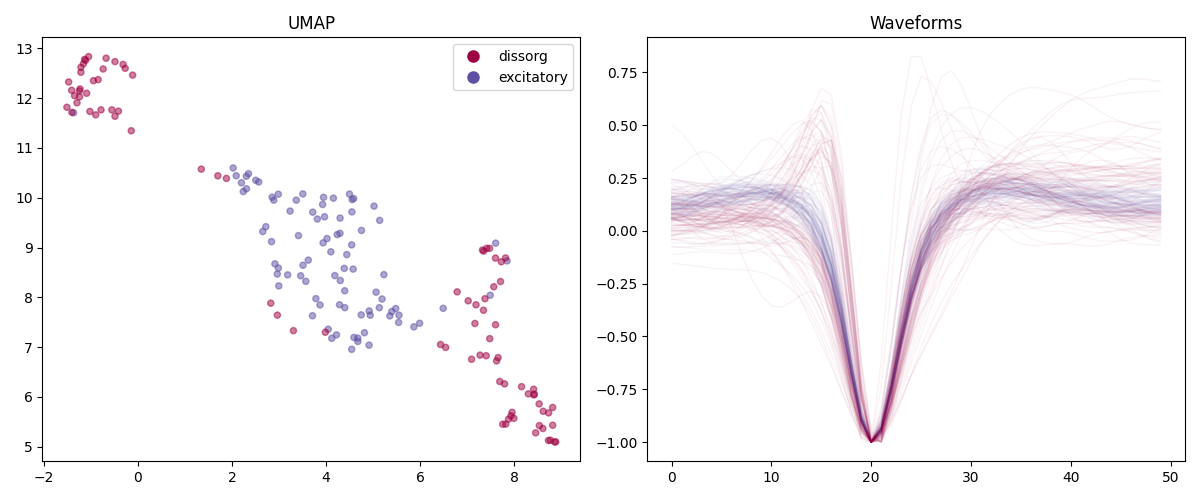

In [9]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# Run UMAP
umap_df, clustering_solution = run_umap(all_wf, all_labels, n_nb=15, min_d=0.1, n_comps=2, metric='euclidean', random_state=RAND_STATE)

# Plot UMAP
interactive_umap_plot(umap_df, cmap_name="Spectral")

Okay I guess this is still quite messy. Next thing.

-----

## Try using the brw extractions instead

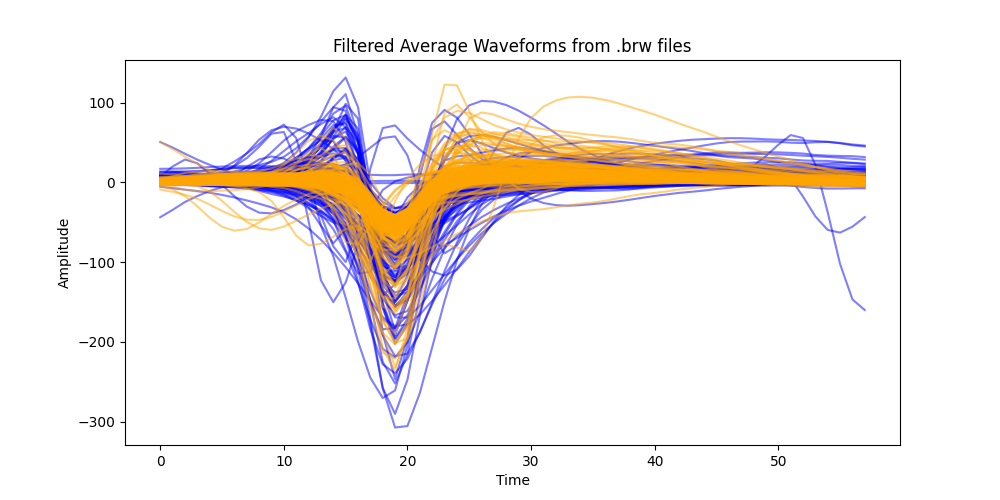

In [10]:
# See how the filtered average waves look at the moment
data_path_dissorg = "d:\\MasterThesis\\analyzer_output\\test_data\\average_waveforms_filtered3.csv"
data_path_excit = "d:\\MasterThesis\\analyzer_output\\excit_data\\average_waveforms_excit_filtered3.csv"

wf_dissorg = np.loadtxt(data_path_dissorg, delimiter=',', dtype=float)
wf_excit = np.loadtxt(data_path_excit, delimiter=',', dtype=float)

# Plot the waveforms
plt.figure(figsize=(10, 5))
plt.plot(wf_dissorg.T, color='blue', alpha=0.5, label='Dissorg')
plt.plot(wf_excit.T, color='orange', alpha=0.5, label='Excitatory')
plt.title('Filtered Average Waveforms from .brw files')
plt.xlabel('Time')
#plt.xlim(15,25)
plt.ylabel('Amplitude')
plt.show()

### NEW FILTERING


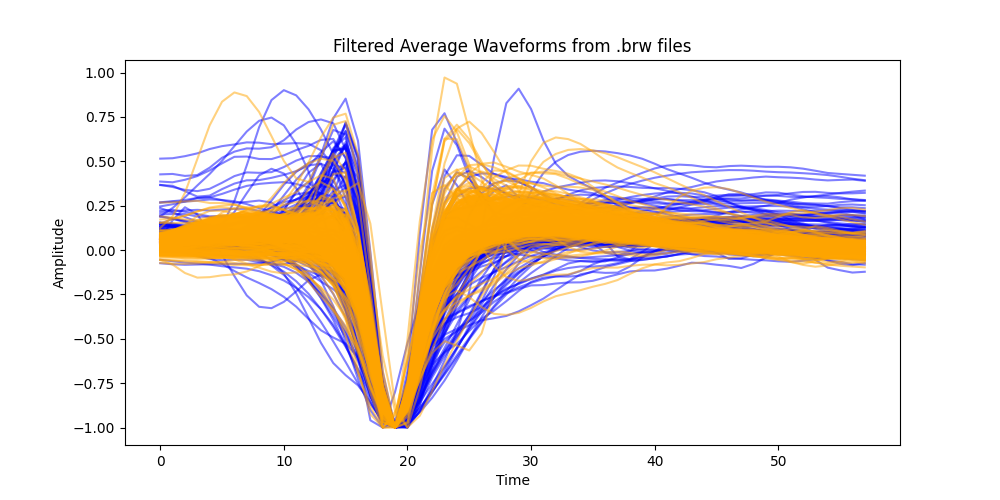

In [11]:
# NEW FILTERING

data_path_dissorg = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_dissorg.csv"
data_path_excit = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_excit.csv"

wf_dissorg = np.loadtxt(data_path_dissorg, delimiter=',', dtype=float)
wf_excit = np.loadtxt(data_path_excit, delimiter=',', dtype=float)

# Plot the waveforms
plt.figure(figsize=(10, 5))
plt.plot(wf_dissorg.T[:,:], color='blue', alpha=0.5, label='Dissorg')
plt.plot(wf_excit.T[:,:], color='orange', alpha=0.5, label='Excitatory')
plt.title('Filtered Average Waveforms from .brw files')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

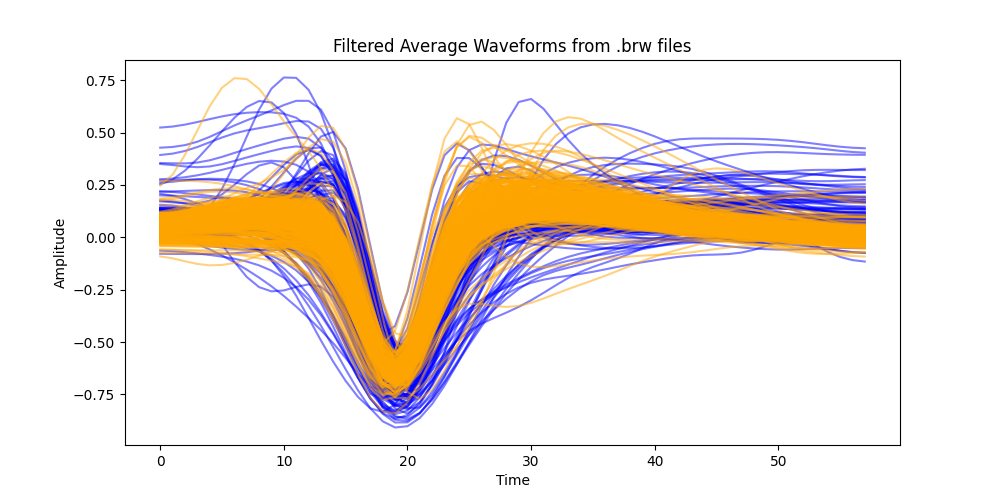

In [12]:
# Load the data
data_path_dissorg = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_dissorg.csv"
data_path_excit = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_excit.csv"

normWF_dissorg = np.loadtxt(data_path_dissorg, delimiter=',', dtype=float)
normWF_excit = np.loadtxt(data_path_excit, delimiter=',', dtype=float)

dissorg_smooth = gaussian_filter1d(normWF_dissorg,sigma=2,axis=-1)
excit_smooth = gaussian_filter1d(normWF_excit,sigma=2,axis=-1)

# Combine the datasets
all_wf = np.vstack([dissorg_smooth, excit_smooth])

# Keep track of origin
dataset_labels = (['dissorg'] * len(dissorg_smooth) + ['excit'] * len(excit_smooth))

plt.figure(figsize=(10, 5))
plt.plot(dissorg_smooth.T[:,:], color='blue', alpha=0.5, label='Dissorg')
plt.plot(excit_smooth.T[:,:], color='orange', alpha=0.5, label='Excitatory')
plt.title('Filtered Average Waveforms from .brw files')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

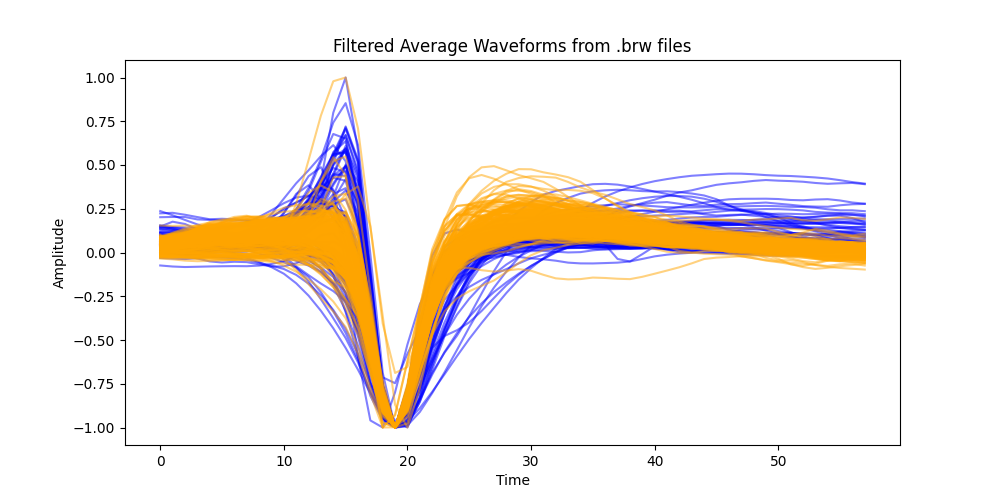

In [13]:
# NEW FILTERING

data_path_dissorg = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_dissorg_noflip.csv"
data_path_excit = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_excit_noflip.csv"

wf_dissorg = np.loadtxt(data_path_dissorg, delimiter=',', dtype=float)
wf_excit = np.loadtxt(data_path_excit, delimiter=',', dtype=float)

def filter_by_initial_values(waveforms, unit_ids, isteps=5, max_amp=0.25):
    keep_mask = np.all(waveforms[:, :isteps] <= max_amp, axis=1)

    return waveforms[keep_mask], unit_ids[keep_mask]

wf_dissorg_noflip25 = filter_by_initial_values(wf_dissorg, np.arange(len(wf_dissorg)), isteps=10, max_amp=0.25)[0]
wf_excit_noflip25 = filter_by_initial_values(wf_excit, np.arange(len(wf_excit)), isteps=10, max_amp=0.25)[0]

np.savetxt("d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_dissorg_noflip25.csv", wf_dissorg_noflip25, delimiter=",")
np.savetxt("d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_excit_noflip25.csv", wf_excit_noflip25, delimiter=",")

# Plot the waveforms
plt.figure(figsize=(10, 5))
plt.plot(wf_dissorg_noflip25.T[:,:], color='blue', alpha=0.5, label='Dissorg')
plt.plot(wf_excit_noflip25.T[:,:], color='orange', alpha=0.5, label='Excitatory')
plt.title('Filtered Average Waveforms from .brw files')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

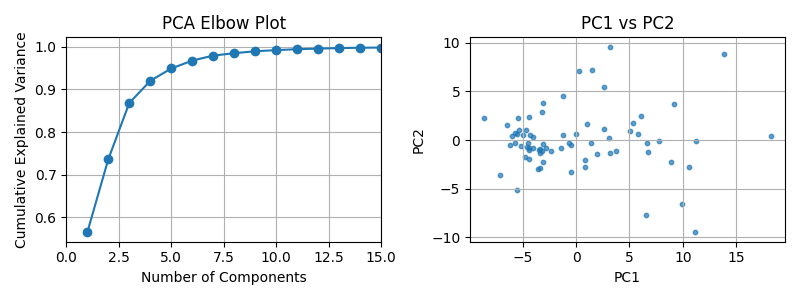

Components that explain 90% of variance: 4


In [70]:
data_path_dissorg = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_dissorg_noflip25.csv"
data_path_excit = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_excit_noflip25.csv"

data_list = [data_path_dissorg]   # data_path_excit, 
data_labels = ['dissorg']    # 'excitatory', 

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels)

# Run PCA
X_pca, pca, nc = run_pca(all_wf, n_exp_var = 0.9,plot = True)
print("Components that explain 90% of variance:", nc)


adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


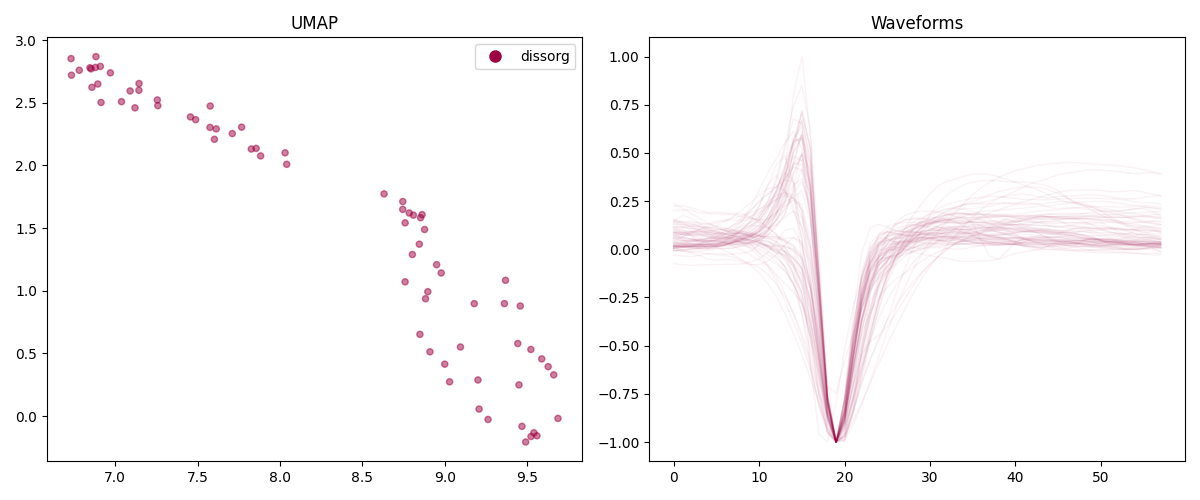

In [90]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# Run UMAP
umap_df, clustering_solution = run_umap(all_wf, all_labels, n_nb=15, min_d=0.1, n_comps=10, resolution = 3, metric='euclidean', random_state=RAND_STATE)

# Plot UMAP
interactive_umap_plot(umap_df, cmap_name="Spectral")

In [91]:
umap_df["dataset"].unique()

array(['dissorg'], dtype=object)

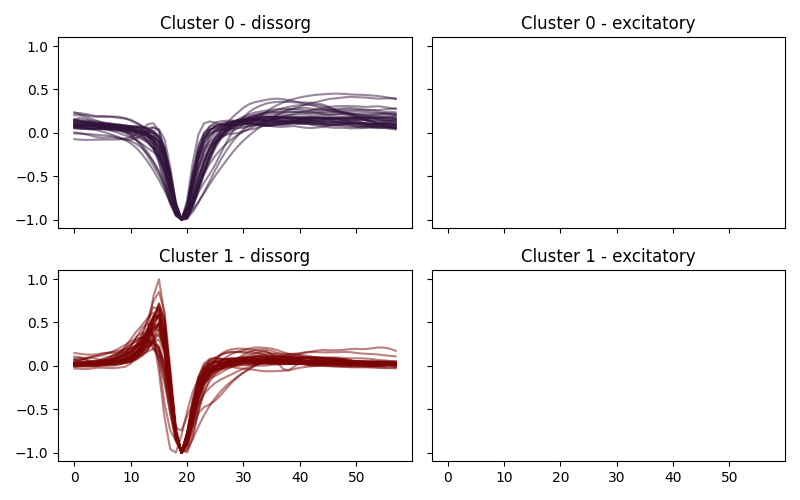

In [92]:
clusters = umap_df['cluster_id'].unique()
n_clusters = len(clusters)

fig, axes = plt.subplots(
    n_clusters, 2,
    figsize=(8, 2.5 * n_clusters),
    sharex=True,
    sharey=True
)

# Handle the case of a single cluster
if n_clusters == 1:
    axes = axes.reshape(1, 2)

for row, cluster in enumerate(clusters):

    dissorg_data = umap_df[
        (umap_df['cluster_id'] == cluster) &
        (umap_df['dataset'] == 'dissorg')
    ]

    excitatory_data = umap_df[
        (umap_df['cluster_id'] == cluster) &
        (umap_df['dataset'] == 'excitatory')
    ]

    ax_left = axes[row, 0]
    ax_right = axes[row, 1]

    for wf in dissorg_data['waveform']:
        ax_left.plot(
            wf,
            alpha=0.5,
            color=dissorg_data['cluster_color'].iloc[0]
        )

    for wf in excitatory_data['waveform']:
        ax_right.plot(
            wf,
            alpha=0.5,
            color=excitatory_data['cluster_color'].iloc[0]
        )

    ax_left.set_title(f"Cluster {cluster} - dissorg")
    ax_right.set_title(f"Cluster {cluster} - excitatory")

plt.tight_layout()
plt.show()

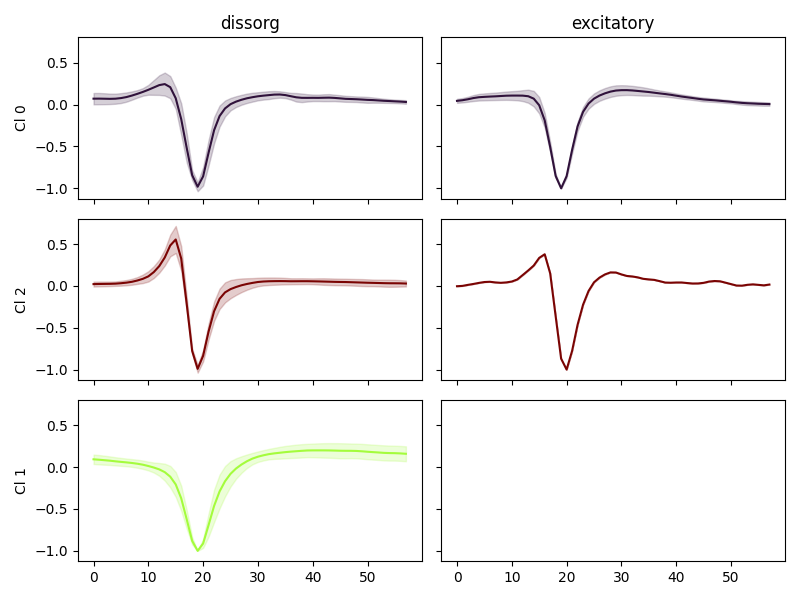

In [ ]:
fig, axes = plt.subplots(
    n_clusters, 2,
    figsize=(8, 2 * n_clusters),
    sharex=True,
    sharey=True
)

if n_clusters == 1:
    axes = axes.reshape(1, 2)

for row, cluster in enumerate(clusters):

    dissorg_data = umap_df[
        (umap_df['cluster_id'] == cluster) &
        (umap_df['dataset'] == 'dissorg')
    ]

    excitatory_data = umap_df[
        (umap_df['cluster_id'] == cluster) &
        (umap_df['dataset'] == 'excitatory')
    ]

    ax_left = axes[row, 0]
    ax_right = axes[row, 1]

    # Dissorg
    if len(dissorg_data) > 0:
        waves = np.vstack(dissorg_data['waveform'])
        mean = waves.mean(axis=0)
        std = waves.std(axis=0)

        ax_left.plot(mean, color=dissorg_data['cluster_color'].iloc[0])
        ax_left.fill_between(
            range(len(mean)),
            mean - std,
            mean + std,
            alpha=0.2,
            color=dissorg_data['cluster_color'].iloc[0]
        )

    # Excitatory
    if len(excitatory_data) > 0:
        waves = np.vstack(excitatory_data['waveform'])
        mean = waves.mean(axis=0)
        std = waves.std(axis=0)

        ax_right.plot(mean, color=excitatory_data['cluster_color'].iloc[0])
        ax_right.fill_between(
            range(len(mean)),
            mean - std,
            mean + std,
            alpha=0.2,
            color=excitatory_data['cluster_color'].iloc[0]
        )

    ax_left.set_ylabel(f"Cl {cluster}")

axes[0, 0].set_title("dissorg")
axes[0, 1].set_title("excitatory")

plt.tight_layout()
plt.show()

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


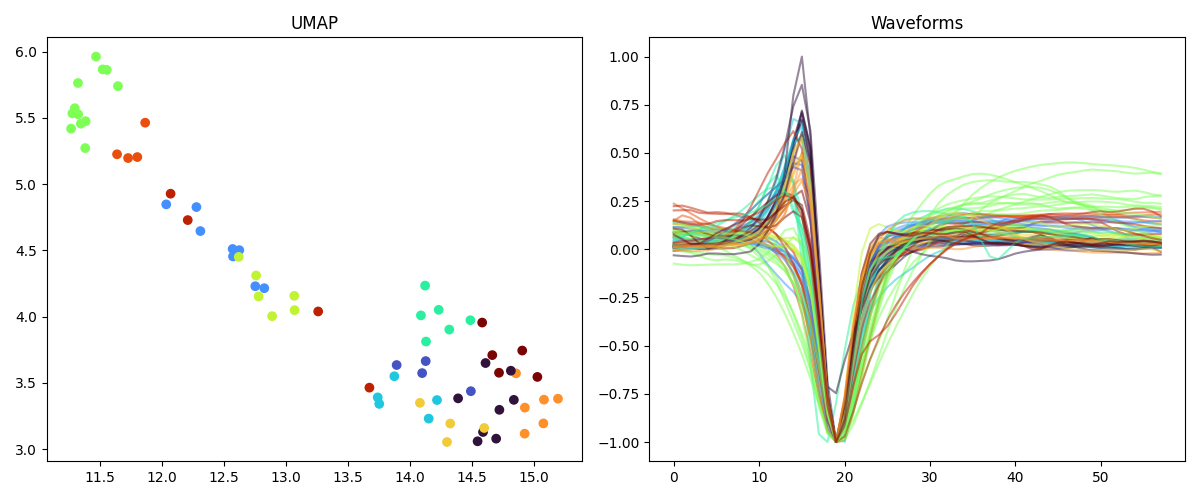

In [89]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)
n_comps = 5

# TEST
#normWFs = unnormWFs     # Mh, the unnormalised one kind of looks better... Maybe need to find a better way to normalise

####### UMAP dimensionality reduction  ########
reducer = umap.UMAP(random_state = RAND_STATE, n_neighbors = 15, n_components=n_comps)    #15
mapper = reducer.fit(all_wf)
G = nx.from_scipy_sparse_array(mapper.graph_)
clustering = cylouvain.best_partition(G, resolution = 0.3, )    #2
clustering_solution = list(clustering.values())

embedding = reducer.fit_transform(all_wf)
col_names = [f'umap_{i+1}' for i in range(n_comps)]
umap_df = pd.DataFrame(embedding, columns=col_names)
umap_df['waveform'] = list(all_wf)
umap_df['cluster_id'] = clustering_solution
cmap = plt.get_cmap("turbo")
colors = cmap(np.linspace(0, 1, len(set(clustering_solution))))
umap_df['cluster_color'] = [colors[i] for i in clustering_solution]

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# 1) UMAP scatter plot
# -------------------------
sc = axes[0].scatter(
    umap_df[col_names[0]],
    umap_df[col_names[1]],
    c=umap_df['cluster_id'],
    cmap='turbo',
    marker='o'
)

axes[0].set_title("UMAP")

# -------------------------
# 2) Waveforms
# -------------------------
for i, wf in enumerate(umap_df['waveform']):
    axes[1].plot(
        wf,
        color=umap_df['cluster_color'].iloc[i],
        alpha=0.5
    )

axes[1].set_title("Waveforms")

plt.tight_layout()
plt.show()

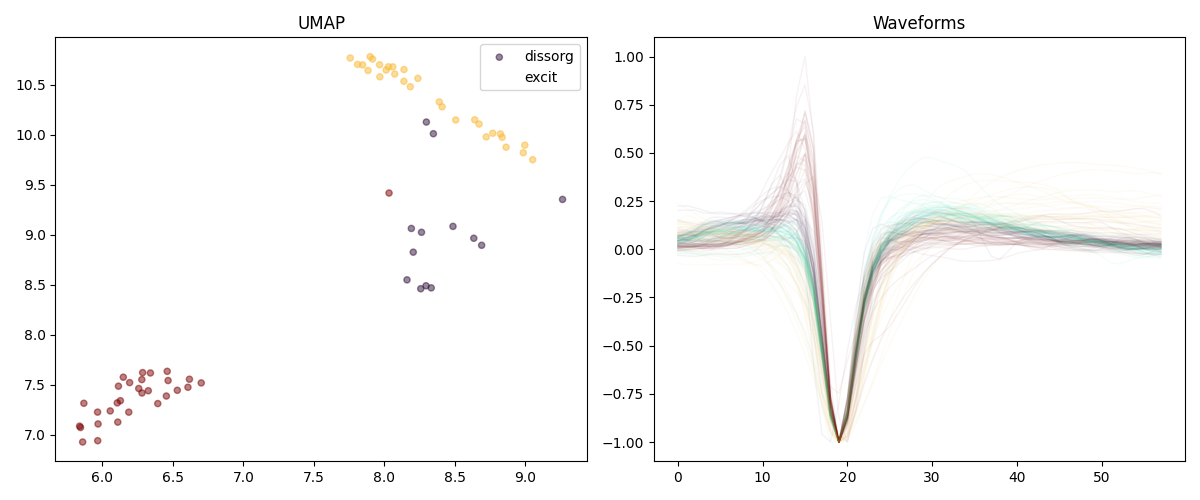

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# 1) UMAP scatter
# -------------------------
marker_map = {'dissorg': 'o','excit': '*'}

for dataset, marker in marker_map.items():

    subset = umap_df[umap_df['dataset'] == dataset]

    sc=axes[0].scatter(
        subset['umap_1'],
        subset['umap_2'],
        c=subset['cluster_id'],
        cmap='turbo',
        marker=marker,
        s=20,
        picker=True,
        label=dataset,
        alpha=0.5
    )
axes[0].legend()
axes[0].set_title("UMAP")

# -------------------------
# 2) Background waveforms
# -------------------------
for i, wf in enumerate(umap_df['waveform']):
    axes[1].plot(
        wf,
        color=umap_df['cluster_color'].iloc[i],
        alpha=0.05,
        linewidth=1
    )

axes[1].set_title("Waveforms")

# -------------------------
# Highlighted waveform
# -------------------------
highlight_line, = axes[1].plot(
    [],
    [],
    linewidth=3
)

# -------------------------
# CLICK interaction
# -------------------------
cursor = mplcursors.cursor([sc], hover=False)

@cursor.connect("add")
def on_click(sel):

    idx = sel.index
    wf = umap_df['waveform'].iloc[idx]

    # update highlighted waveform
    highlight_line.set_data(
        np.arange(len(wf)),
        wf
    )

    # match waveform color
    highlight_line.set_color(
        umap_df['cluster_color'].iloc[idx]
    )

    # rescale waveform axis if needed
    axes[1].relim()
    axes[1].autoscale_view()

    fig.canvas.draw_idle()

plt.tight_layout()
plt.show()

Could delete any other waves containing other negative prominent peaks?

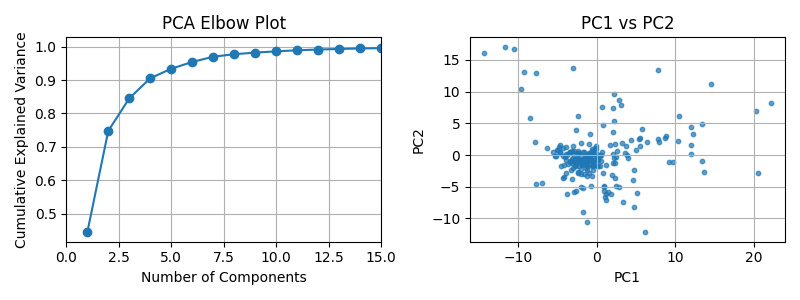

Components that explain 90% of variance: 4


In [17]:
data_path_dissorg = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_dissorg.csv"
data_path_excit = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_excit.csv"

data_list = [data_path_excit, data_path_dissorg]
data_labels = ['excitatory', 'dissorg']

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels)

# Run PCA
X_pca, pca, nc = run_pca(all_wf, n_exp_var = 0.9,plot = True)
print("Components that explain 90% of variance:", nc)

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


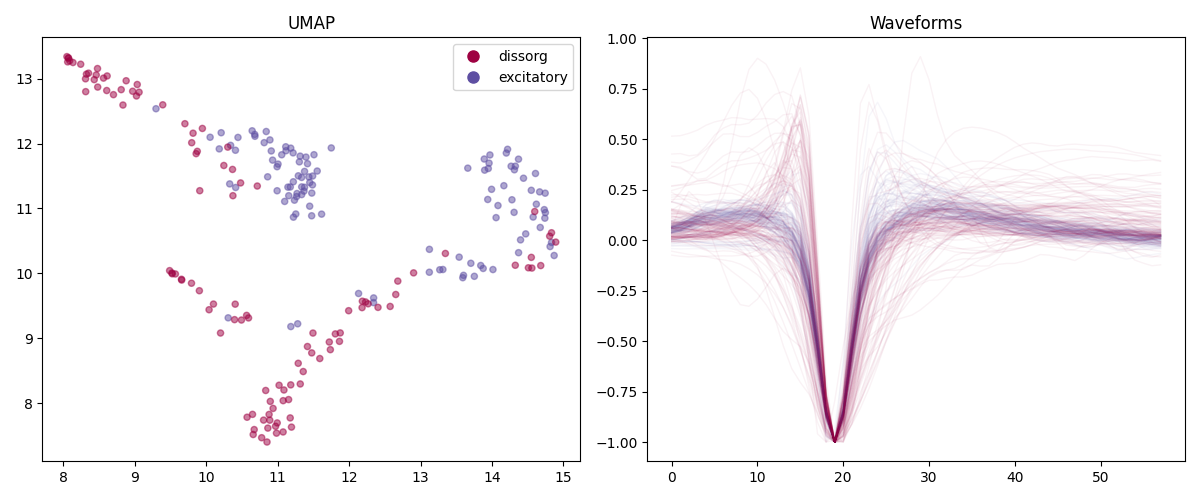

In [18]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# Run UMAP
umap_df, clustering_solution = run_umap(all_wf, all_labels, n_nb=15, min_d=0.1, n_comps=5, metric='euclidean', random_state=RAND_STATE)

# Plot UMAP
interactive_umap_plot(umap_df, cmap_name="Spectral")

In [19]:
# Load the data
data_path_dissorg = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_dissorg.csv"
data_path_excit = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_excit.csv"

normWF_dissorg = np.loadtxt(data_path_dissorg, delimiter=',', dtype=float)
normWF_excit = np.loadtxt(data_path_excit, delimiter=',', dtype=float)

dissorg_smooth = gaussian_filter1d(normWF_dissorg,sigma=1,axis=-1)
excit_smooth = gaussian_filter1d(normWF_excit,sigma=1,axis=-1)

# Combine the datasets
all_wf = np.vstack([dissorg_smooth, excit_smooth])

# Keep track of origin
dataset_labels = (['dissorg'] * len(dissorg_smooth) + ['excit'] * len(excit_smooth))


Pass `objective` as keyword args.
ntree_limit is deprecated, use `iteration_range` or model slicing instead.


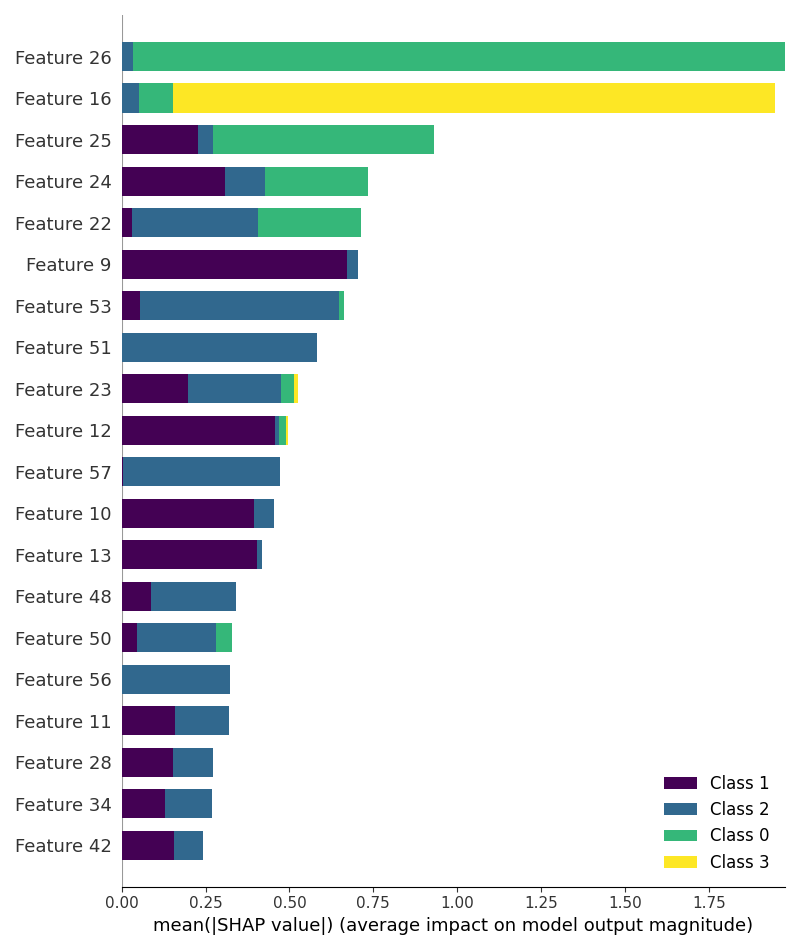

In [20]:
import shap 
import xgboost as xgb 
from wavemap_paper.helper_functions import train_gridsearch_classifier, plot_confusion_matrix 
umap_model, conf_mat = train_gridsearch_classifier(umap_df)
import matplotlib as mpl 

xgbModel = xgb.XGBClassifier(umap_model.best_params_) 
xgbModel.fit(umap_df['waveform'].tolist(),umap_df['cluster_id'].tolist()) 
explainer = shap.TreeExplainer(xgbModel)

plt.close('all')
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0,1,len(set(clustering_solution))))
umap_cmap = mpl.colors.ListedColormap(colors, name='umap_cmap') 
shap_values = explainer.shap_values(umap_df['waveform'].tolist()) 
shap.summary_plot(shap_values, color = umap_cmap)

------

Find out what these features are!

In [96]:
print(help(explainer))

Help on Tree in module shap.explainers._tree object:

class Tree(shap.explainers._explainer.Explainer)
 |  Tree(model, data=None, model_output='raw', feature_perturbation='interventional', feature_names=None, approximate=False, **deprecated_options)
 |  
 |  Uses Tree SHAP algorithms to explain the output of ensemble tree models.
 |  
 |  Tree SHAP is a fast and exact method to estimate SHAP values for tree models and ensembles of trees,
 |  under several different possible assumptions about feature dependence. It depends on fast C++
 |  implementations either inside an externel model package or in the local compiled C extention.
 |  
 |  Method resolution order:
 |      Tree
 |      shap.explainers._explainer.Explainer
 |      shap._serializable.Serializable
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __call__(self, X, y=None, interactions=False, check_additivity=True)
 |      Explains the output of model(*args), where args is a list of parallel iteratable datasets

In [101]:
len(shap_values)

4